Working directory: /Users/subash110sh/Documents/Subash/ml/IFM/code/models/sota
Total days : 2313
Train size : 1850
Test size  : 463


Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 44620.26it/s]


TimesFM model loaded successfully
Period 7 done — 462 days evaluated
Period 14 done — 462 days evaluated
Period 30 done — 450 days evaluated
--------------------------------------------------
Window              MAE         RMSE       MAPE
--------------------------------------------------
7 days           4634.46      8843.20     12.99%
14 days           5851.60     11277.55     15.87%
30 days           8923.14     16323.44     23.74%
--------------------------------------------------


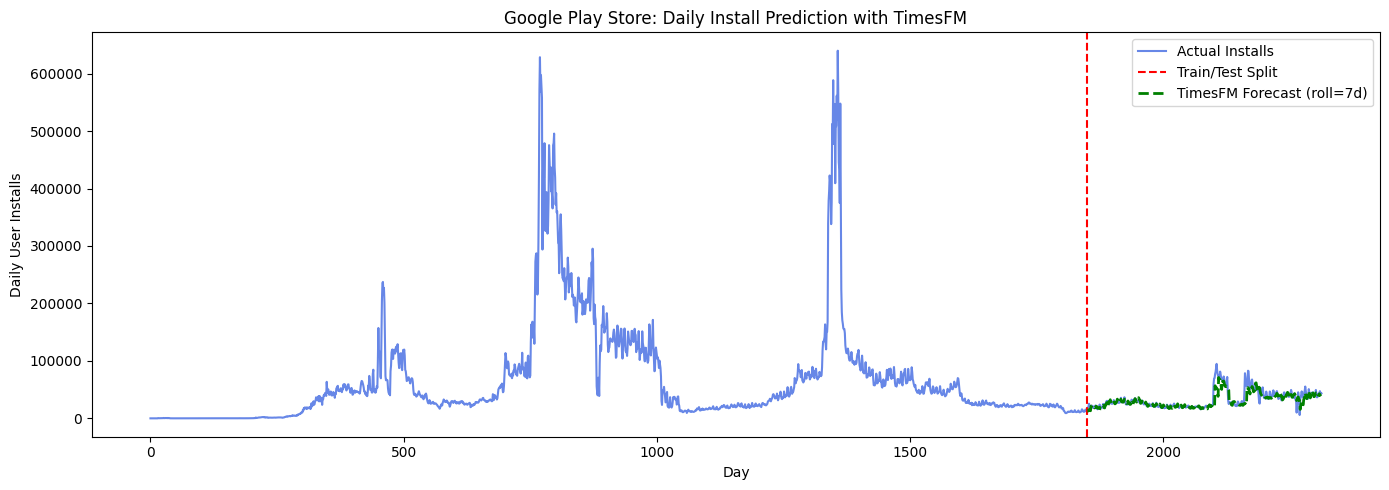

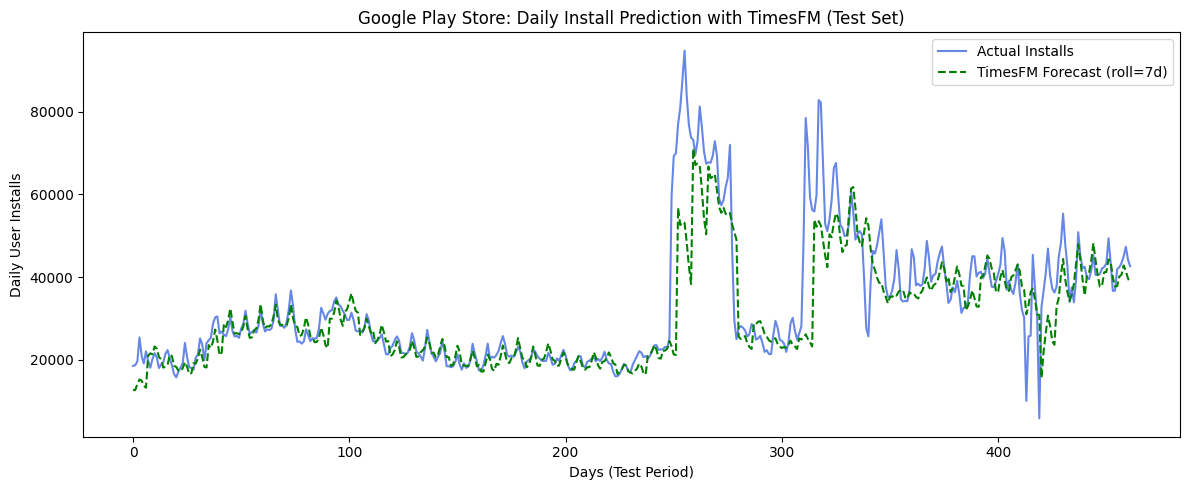

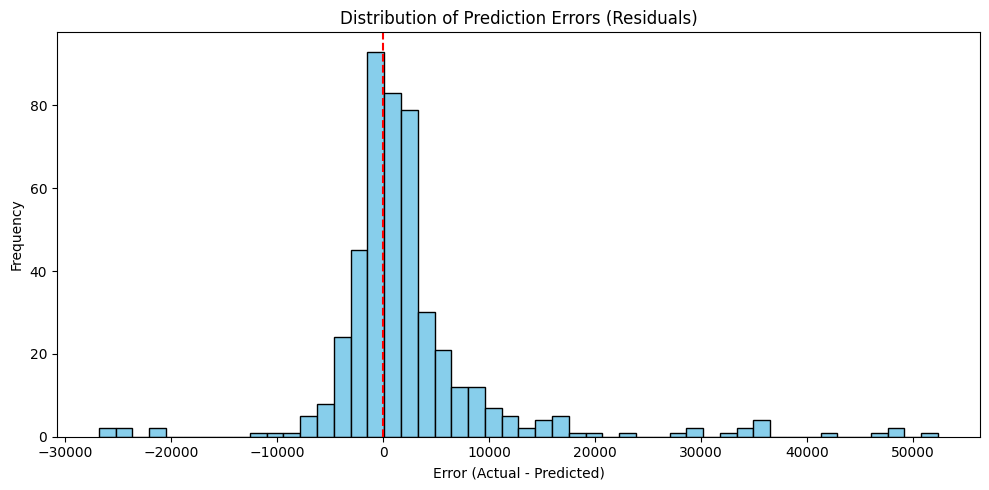

Model metadata saved to timesfm_model_meta.json


In [24]:
import os
import random
import numpy as np
import pandas as pd
import timesfm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set working directory
os.chdir("/Users/subash110sh/Documents/Subash/ml/IFM/code/models/sota")
print(f"Working directory: {os.getcwd()}")

# ── Hyperparameters ───────────────────────────────────────
SEED        = 42
TRAIN_RATIO = 0.8
DATA_CSV_FILE = "../../../data/ds_data_clean.csv"
# ─────────────────────────────────────────────────────────

random.seed(SEED)
np.random.seed(SEED)

# 1. Load Data
df = pd.read_csv(DATA_CSV_FILE)
df["Date"] = pd.to_datetime(df["Date"])
data_series = df["Daily User Installs"].values.astype(np.float32)

# 2. Train/Test Split (same 80/20 as Prophet)
split_idx    = int(len(data_series) * TRAIN_RATIO)
train_series = data_series[:split_idx]
test_series  = data_series[split_idx:]

print(f"Total days : {len(data_series)}")
print(f"Train size : {len(train_series)}")
print(f"Test size  : {len(test_series)}")

# 3. Initialize TimesFM Model
tfm = timesfm.TimesFm(
    hparams=timesfm.TimesFmHparams(
        context_len=128,
        horizon_len=30,
        input_patch_len=32,
        output_patch_len=128,
        backend="torch",
    ),
    checkpoint=timesfm.TimesFmCheckpoint(
        huggingface_repo_id="google/timesfm-1.0-200m-pytorch"
    ),
)
print("TimesFM model loaded successfully")

# 4. Rolling Forecast function
def rolling_forecast(series_context, test_series, roll_period):
    preds = []
    acts  = []

    for i in range(0, len(test_series) - roll_period + 1, roll_period):
        window_actuals = test_series[i:i + roll_period]
        if len(window_actuals) < roll_period:
            break

        # Context = all training data + already seen test data
        context = np.concatenate([series_context, test_series[:i]])

        # TimesFM needs at least context_len points
        context_input = context[-128:] if len(context) >= 128 else context

        forecast_output, _ = tfm.forecast([context_input], freq=[0])
        window_preds = forecast_output[0][:roll_period]

        preds.extend(window_preds)
        acts.extend(window_actuals)

    preds = np.maximum(np.array(preds), 0)
    acts  = np.array(acts)
    return preds, acts

# 5. Compare Multiple Roll Periods
results = {}

for period in [7, 14, 30]:
    preds, acts = rolling_forecast(train_series, test_series, period)
    results[period] = {
        "MAE"  : mean_absolute_error(acts, preds),
        "RMSE" : np.sqrt(mean_squared_error(acts, preds)),
        "MAPE" : np.mean(np.abs((acts - preds) / (acts + 1e-8))) * 100,
        "preds": preds,
        "acts" : acts,
    }
    print(f"Period {period} done — {len(acts)} days evaluated")

# 6. Print comparison table
print("-" * 50)
print(f"{'Window':<10} {'MAE':>12} {'RMSE':>12} {'MAPE':>10}")
print("-" * 50)
for period, metrics in results.items():
    print(f"{period} days{'':<5} {metrics['MAE']:>12.2f} {metrics['RMSE']:>12.2f} {metrics['MAPE']:>9.2f}%")
print("-" * 50)

# 7. Full series plot (using 7-day predictions)
preds_7d = results[7]["preds"]
acts_7d  = results[7]["acts"]

plt.figure(figsize=(14, 5))
plt.plot(range(len(data_series)), data_series,
         label="Actual Installs", color="royalblue", alpha=0.8)
plt.axvline(x=split_idx, color="red", linestyle="--", label="Train/Test Split")
plt.plot(range(split_idx, split_idx + len(preds_7d)), preds_7d,
         label="TimesFM Forecast (roll=7d)", color="green", linestyle="--", linewidth=2)
plt.title("Google Play Store: Daily Install Prediction with TimesFM")
plt.xlabel("Day")
plt.ylabel("Daily User Installs")
plt.legend()
plt.tight_layout()
plt.savefig("timesfm_forecast_plot.png")
plt.show()

# 8. Test period plot
plt.figure(figsize=(12, 5))
plt.plot(acts_7d, label="Actual Installs", color="royalblue", alpha=0.8)
plt.plot(preds_7d, label="TimesFM Forecast (roll=7d)", color="green", linestyle="--")
plt.title("Google Play Store: Daily Install Prediction with TimesFM (Test Set)")
plt.xlabel("Days (Test Period)")
plt.ylabel("Daily User Installs")
plt.legend()
plt.tight_layout()
plt.savefig("timesfm_test_forecast_plot.png")
plt.show()

# 9. Error Distribution Plot
errors = acts_7d - preds_7d
plt.figure(figsize=(10, 5))
plt.hist(errors, bins=50, color="skyblue", edgecolor="black")
plt.axvline(0, color="red", linestyle="--")
plt.title("Distribution of Prediction Errors (Residuals)")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("timesfm_error_distribution.png")
plt.show()

import json

timesfm_checkpoint = {
    "model_type"  : "TimesFM",
    "target_col"  : "Daily User Installs",
    "train_ratio" : float(TRAIN_RATIO),
    "seed"        : int(SEED),
    "context_len" : 128,
    "horizon_len" : 30,
    "backend"     : "torch",
    "results"     : {
        str(k): {
            "MAE" : round(float(v["MAE"]), 2),
            "RMSE": round(float(v["RMSE"]), 2),
            "MAPE": round(float(v["MAPE"]), 2)
        }
        for k, v in results.items()
    }
}

with open("timesfm_model_meta.json", "w") as f:
    json.dump(timesfm_checkpoint, f, indent=2)

print("Model metadata saved to timesfm_model_meta.json")